In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


(7043, 21)

In [4]:
df['OnlineBackup']

0       Yes
1        No
2       Yes
3        No
4        No
       ... 
7038     No
7039    Yes
7040     No
7041     No
7042     No
Name: OnlineBackup, Length: 7043, dtype: object

In [5]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [6]:
for i in df.columns:
    print("col=",i , df[i].unique())

col= customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
col= gender ['Female' 'Male']
col= SeniorCitizen [0 1]
col= Partner ['Yes' 'No']
col= Dependents ['No' 'Yes']
col= tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
col= PhoneService ['No' 'Yes']
col= MultipleLines ['No phone service' 'No' 'Yes']
col= InternetService ['DSL' 'Fiber optic' 'No']
col= OnlineSecurity ['No' 'Yes' 'No internet service']
col= OnlineBackup ['Yes' 'No' 'No internet service']
col= DeviceProtection ['No' 'Yes' 'No internet service']
col= TechSupport ['No' 'Yes' 'No internet service']
col= StreamingTV ['No' 'Yes' 'No internet service']
col= StreamingMovies ['No' 'Yes' 'No internet service']
col= Contract ['Month-to-month' 'One year' 'Two year']
col= PaperlessBilling ['Yes' 'No']
col= Pay

In [7]:
yes_no_cols = list()
for col in df.columns:
    if set(df[col].dropna().unique()).issubset({'Yes', 'No'}):
        yes_no_cols.append(col)

In [8]:
yes_no_cols

['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

In [9]:
for i in yes_no_cols:
    df[i] = df[i].map({'Yes':1, 'No':0})
    
df['gender'] = df['gender'].map({'Male': 1, "Female": 0})

In [10]:
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1191,8221-HVAYI,1,0,1,1,35,1,Yes,DSL,Yes,...,Yes,Yes,No,No,Two year,1,Credit card (automatic),69.15,2490.15,0
30,3841-NFECX,0,1,1,0,71,1,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,1,Credit card (automatic),96.35,6766.95,0
6089,8775-LHDJH,0,1,1,0,1,1,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,1,Electronic check,90.60,90.6,1
4884,2359-KLTEK,0,0,1,1,41,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,1,Bank transfer (automatic),94.90,3848,0
5837,2969-QWUBZ,0,0,0,0,2,0,No phone service,DSL,No,...,No,No,Yes,Yes,Month-to-month,0,Electronic check,51.40,96.8,0
6581,2453-SAFNS,0,1,0,0,54,1,Yes,DSL,No,...,No,Yes,Yes,No,One year,0,Mailed check,72.10,3886.05,0
5321,7718-UPSKJ,0,0,1,0,69,1,No,Fiber optic,Yes,...,No,Yes,Yes,Yes,One year,1,Credit card (automatic),106.40,7251.9,0
5172,9507-HSMMZ,1,0,0,0,54,1,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.00,1149.65,0
1126,0927-LCSMG,1,0,0,0,7,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,0,Mailed check,74.65,544.55,1
2887,5696-QURRL,1,0,0,0,1,1,No,DSL,No,...,No,No,No,No,Month-to-month,1,Mailed check,45.05,45.05,1


In [11]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [12]:
df = pd.get_dummies(df, columns=[
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod'], drop_first=True, dtype=int)

In [13]:
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3231,9938-EKRGF,0,0,0,0,15,1,0,84.45,1287.85,...,1,0,1,0,1,0,0,0,0,1
6101,4627-MIHJH,0,1,0,0,69,1,0,110.25,7467.55,...,1,0,1,0,1,0,1,1,0,0
1811,2070-XYMFH,0,1,0,0,23,1,1,79.35,1835.3,...,0,0,0,0,0,0,0,0,0,1
615,9396-ZSFLL,0,0,0,0,15,1,0,48.85,631.4,...,0,0,0,0,0,0,0,0,0,1
3361,8659-HDIYE,0,1,0,0,64,1,0,74.65,4869.35,...,1,0,0,0,1,0,0,1,0,0
2014,4418-LZMSV,1,0,1,1,13,1,0,61.80,750.1,...,1,0,0,0,0,0,0,0,0,0
4107,2190-PHBHR,0,0,1,0,72,1,1,94.45,6921.7,...,0,0,0,0,1,0,1,1,0,0
4190,3737-GCSPV,0,0,1,0,11,1,1,96.20,1222.05,...,1,0,1,0,0,0,0,1,0,0
2035,8100-HZZLJ,0,0,0,1,43,1,1,63.95,2737.05,...,0,0,0,0,1,0,0,0,1,0
4021,4255-DDUOU,0,0,1,1,1,1,1,20.50,20.5,...,0,1,0,1,0,0,0,0,0,1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   gender                                 7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   int64  
 6   PhoneService                           7043 non-null   int64  
 7   PaperlessBilling                       7043 non-null   int64  
 8   MonthlyCharges                         7043 non-null   float64
 9   TotalCharges                           7043 non-null   object 
 10  Churn                                  7043 non-null   int64  
 11  Mult

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'].fillna(0, inplace=True) 

In [16]:
df.dtypes

customerID                                object
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes

In [17]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import seaborn as sns

# # Create pairplot with hue
# sns.pairplot(df, hue="Churn")
# plt.show()

In [18]:
r = df.corr(numeric_only=True)['Churn'].abs().sort_values()
r

gender                                   0.008612
PhoneService                             0.011942
MultipleLines_No phone service           0.011942
MultipleLines_Yes                        0.040102
StreamingMovies_Yes                      0.061382
StreamingTV_Yes                          0.063228
DeviceProtection_Yes                     0.066160
OnlineBackup_Yes                         0.082255
PaymentMethod_Mailed check               0.091683
PaymentMethod_Credit card (automatic)    0.134302
Partner                                  0.150448
SeniorCitizen                            0.150889
Dependents                               0.164221
TechSupport_Yes                          0.164674
OnlineSecurity_Yes                       0.171226
Contract_One year                        0.177820
PaperlessBilling                         0.191825
MonthlyCharges                           0.193356
TotalCharges                             0.198324
StreamingTV_No internet service          0.227890


In [22]:
filltered_features = list()

for i in r.index: 
    if r[i] > 0.09 and i != "Churn":
        filltered_features.append(i)

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

AUC-ROC Score: 0.8155

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.70      0.79      1035
           1       0.50      0.82      0.62       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.73      0.75      1409



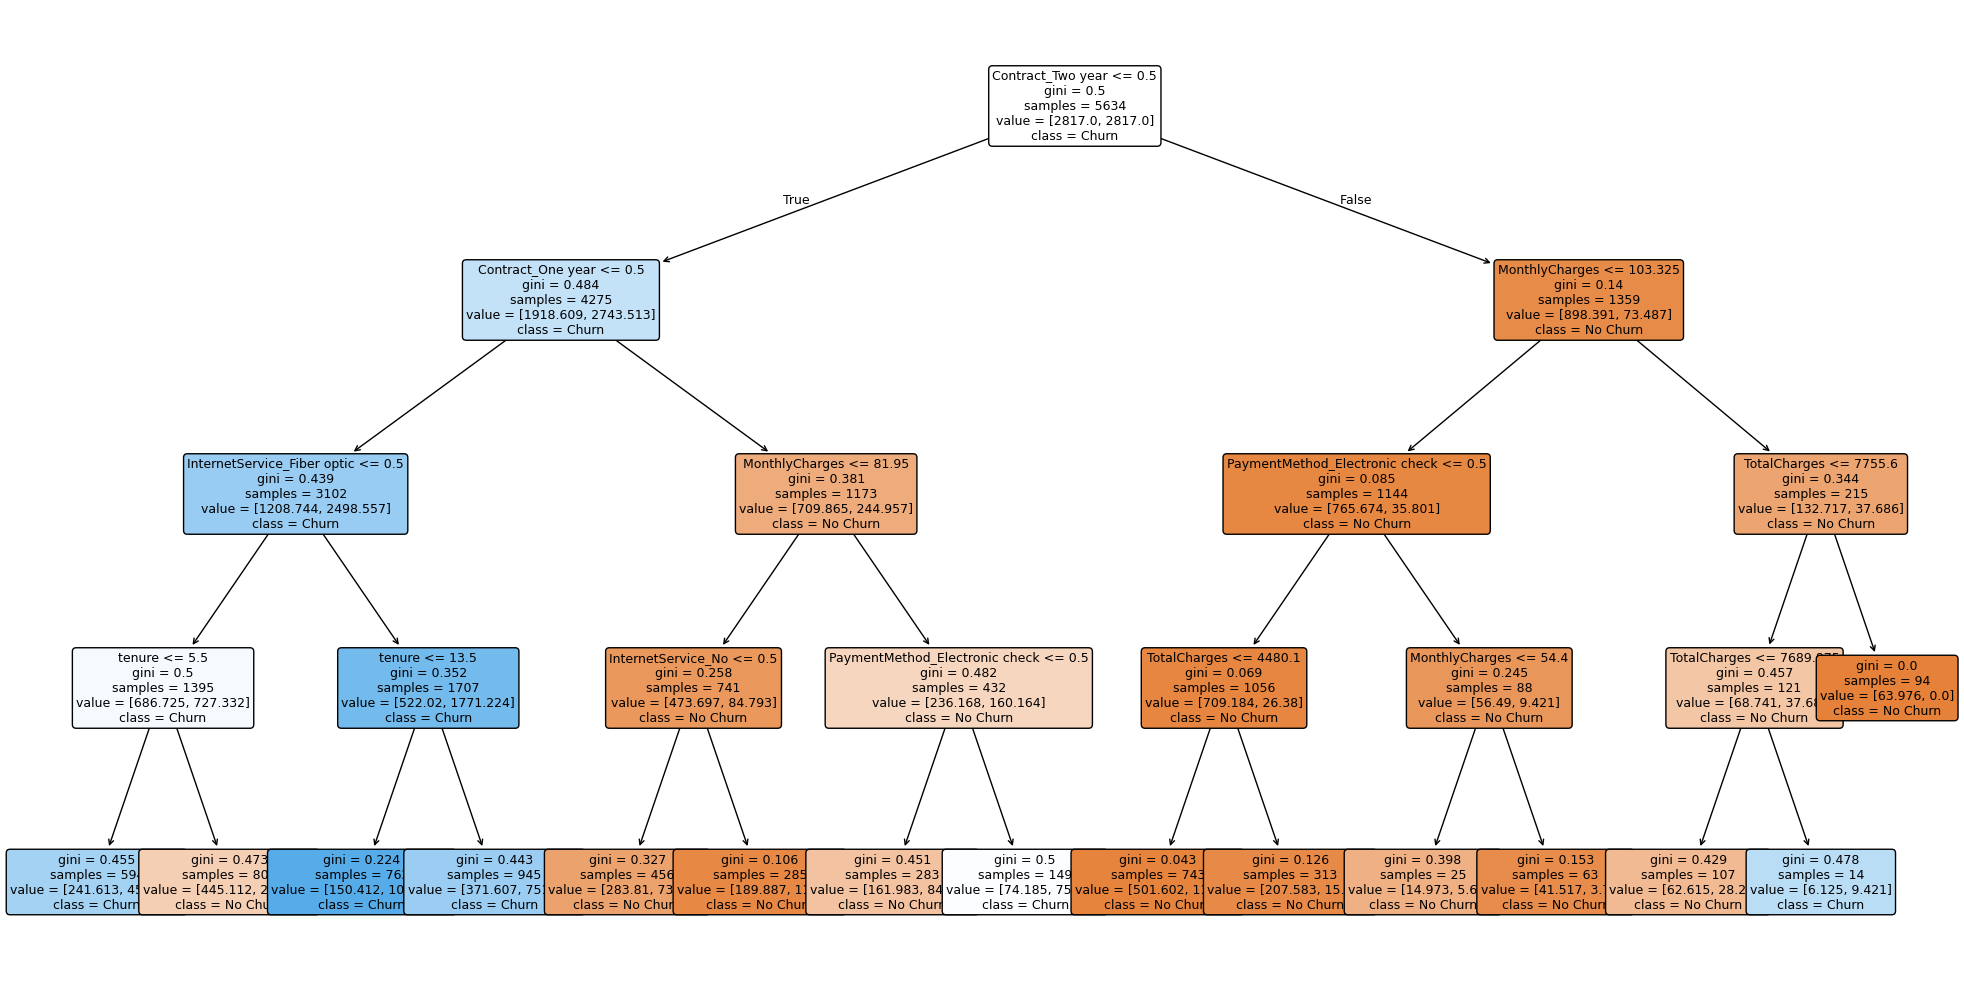

In [28]:
X = df[filltered_features]
y = df['Churn']

# 2. Train-Test Split (stratified to maintain churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Initialize and train Decision Tree
# max_depth prevents overfitting; class_weight='balanced' addresses churn imbalance
dt_model = DecisionTreeClassifier(
    max_depth=4, class_weight='balanced', random_state=42
)
dt_model.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:, 1]

print('AUC-ROC Score:', round(roc_auc_score(y_test, y_prob), 4))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

# 5. Visualize the Tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=filltered_features,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.tight_layout()
plt.show()

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Feature selection from your filtered list
X = df[filltered_features]
y = df['Churn']

# 2. Train-Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale continuous numerical features (crucial for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Logistic Regression
# class_weight='balanced' handles churn class imbalance
lr_model = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=42
)
lr_model.fit(X_train_scaled, y_train)

# 5. Predict & Evaluate
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print("AUC-ROC Score:", round(roc_auc_score(y_test, y_prob), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

AUC-ROC Score: 0.8393

Confusion Matrix:
 [[737 298]
 [ 74 300]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

